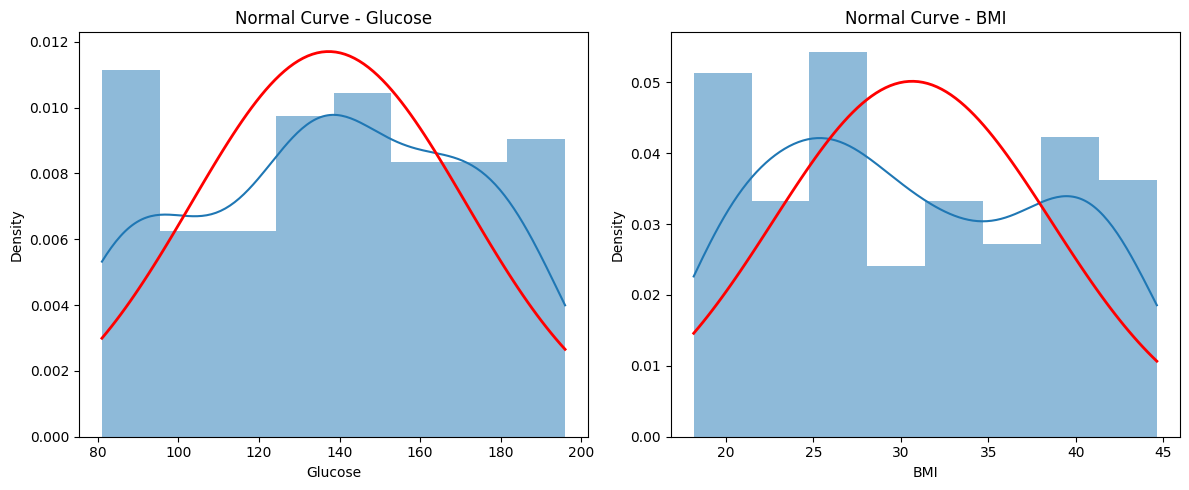

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Create Sample UCI Diabetes Dataset
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BMI": np.random.uniform(18, 45, 100)
})

# Plot Normal Curves for Glucose and BMI
plt.figure(figsize=(12, 5))

# ---------------- Glucose ----------------
plt.subplot(1, 2, 1)

sns.histplot(
    uci_diabetes["Glucose"],
    kde=True,
    stat="density",
    linewidth=0
)

x = np.linspace(
    uci_diabetes["Glucose"].min(),
    uci_diabetes["Glucose"].max(),
    100
)

plt.plot(
    x,
    norm.pdf(
        x,
        uci_diabetes["Glucose"].mean(),
        uci_diabetes["Glucose"].std()
    ),
    'r',
    linewidth=2
)

plt.title("Normal Curve - Glucose")
plt.xlabel("Glucose")
plt.ylabel("Density")

# ---------------- BMI ----------------
plt.subplot(1, 2, 2)

sns.histplot(
    uci_diabetes["BMI"],
    kde=True,
    stat="density",
    linewidth=0
)

x = np.linspace(
    uci_diabetes["BMI"].min(),
    uci_diabetes["BMI"].max(),
    100
)

plt.plot(
    x,
    norm.pdf(
        x,
        uci_diabetes["BMI"].mean(),
        uci_diabetes["BMI"].std()
    ),
    'r',
    linewidth=2
)

plt.title("Normal Curve - BMI")
plt.xlabel("BMI")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [2]:
#4b
# Import Libraries
import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import ztest

# Create Sample UCI Diabetes Dataset
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100)
})

# Perform Z-Test for Glucose (Testing if mean Glucose differs from 100)
z_stat, p_value = ztest(uci_diabetes["Glucose"], value=100)

# Display Results
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: The mean Glucose level is significantly different from 100.")
else:
    print("Fail to reject the null hypothesis: No significant difference in mean Glucose level.")

Z-Statistic: 10.9405
P-Value: 0.0000
Reject the null hypothesis: The mean Glucose level is significantly different from 100.


In [4]:
#4C
# Import Libraries
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Create Sample Datasets
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100)
})

pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100)
})

# Display sample data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Relevant Numerical Columns
numerical_columns = ["Glucose", "BloodPressure", "BMI"]

# Perform Independent T-test
t_test_results = {}

for col in numerical_columns:
    t_stat, p_value = ttest_ind(
        uci_diabetes[col],
        pima_diabetes[col],
        equal_var=False
    )

    t_test_results[col] = {
        "T-statistic": t_stat,
        "P-value": p_value
    }

# Convert Results to DataFrame
t_test_df = pd.DataFrame(t_test_results).T

# Display Results
print("\nT-test Results:")
print(t_test_df)

UCI Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI
0      182             73  21.236365
1      131             90  27.115610
2      172             74  43.458562
3       94             67  26.726479
4      186             73  32.007347

Pima Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI
0      107             81  27.086964
1      190             81  35.704511
2      143             65  28.405709
3      176             74  36.403569
4      148             96  27.196863

T-test Results:
               T-statistic   P-value
Glucose          -0.190666  0.848983
BloodPressure    -0.005885  0.995310
BMI              -1.093699  0.275424


In [5]:
#4D
# Import Libraries
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

# Create Sample Datasets
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100)
})

pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100)
})

# Display Sample Data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Relevant Numerical Columns
numerical_columns = ["Glucose", "BloodPressure", "BMI"]

# Perform One-Way ANOVA
anova_results = {}

for col in numerical_columns:
    f_stat, p_value = f_oneway(
        uci_diabetes[col],
        pima_diabetes[col]
    )

    anova_results[col] = {
        "F-statistic": f_stat,
        "P-value": p_value
    }

# Convert Results to DataFrame
anova_df = pd.DataFrame(anova_results).T

# Display Results
print("\nANOVA Results:")
print(anova_df)

UCI Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI
0      182             73  21.236365
1      131             90  27.115610
2      172             74  43.458562
3       94             67  26.726479
4      186             73  32.007347

Pima Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI
0      107             81  27.086964
1      190             81  35.704511
2      143             65  28.405709
3      176             74  36.403569
4      148             96  27.196863

ANOVA Results:
               F-statistic   P-value
Glucose           0.036353  0.848983
BloodPressure     0.000035  0.995310
BMI               1.196178  0.275416


UCI Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI  Age
0      182             73  21.236365   47
1      131             90  27.115610   66
2      172             74  43.458562   52
3       94             67  26.726479   24
4      186             73  32.007347   67

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI  Age
0      175             83  40.598025   24
1      195             75  41.405455   57
2      173             61  40.638981   22
3      126             87  29.504470   42
4      178             91  24.009563   56

UCI Diabetes Dataset - Linear Regression Results
R2 Score : -0.1886
MSE      : 234.7537
MAE      : 12.7076

Pima Indians Diabetes Dataset - Linear Regression Results
R2 Score : -0.1172
MSE      : 331.3020
MAE      : 16.6735


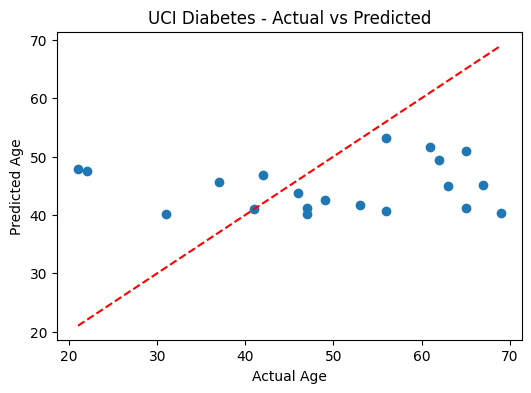

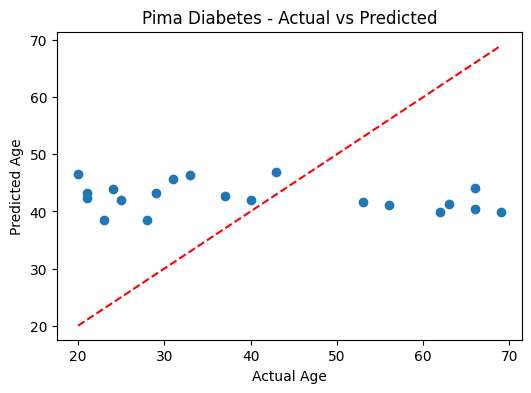

In [8]:
#5A
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Create Sample Datasets
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100),
    "Age": np.random.randint(20, 70, 100)
})

pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100),
    "Age": np.random.randint(20, 70, 100)
})

# Display Sample Data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Age"

# Prepare Data
X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train the Linear Regression Models
model_uci = LinearRegression()
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LinearRegression()
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate UCI Model
r2_uci = r2_score(y_test_uci, y_pred_uci)
mse_uci = mean_squared_error(y_test_uci, y_pred_uci)
mae_uci = mean_absolute_error(y_test_uci, y_pred_uci)

# Evaluate Pima Model
r2_pima = r2_score(y_test_pima, y_pred_pima)
mse_pima = mean_squared_error(y_test_pima, y_pred_pima)
mae_pima = mean_absolute_error(y_test_pima, y_pred_pima)

# Display Results
print("\nUCI Diabetes Dataset - Linear Regression Results")
print(f"R2 Score : {r2_uci:.4f}")
print(f"MSE      : {mse_uci:.4f}")
print(f"MAE      : {mae_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Linear Regression Results")
print(f"R2 Score : {r2_pima:.4f}")
print(f"MSE      : {mse_pima:.4f}")
print(f"MAE      : {mae_pima:.4f}")

# Plot Actual vs Predicted for UCI Dataset
plt.figure(figsize=(6,4))
plt.scatter(y_test_uci, y_pred_uci)
plt.plot(
    [y_test_uci.min(), y_test_uci.max()],
    [y_test_uci.min(), y_test_uci.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("UCI Diabetes - Actual vs Predicted")
plt.show()

# Plot Actual vs Predicted for Pima Dataset
plt.figure(figsize=(6,4))
plt.scatter(y_test_pima, y_pred_pima)
plt.plot(
    [y_test_pima.min(), y_test_pima.max()],
    [y_test_pima.min(), y_test_pima.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Pima Diabetes - Actual vs Predicted")
plt.show()

UCI Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI  Outcome
0      182             73  21.236365        1
1      131             90  27.115610        0
2      172             74  43.458562        1
3       94             67  26.726479        0
4      186             73  32.007347        0

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure        BMI  Outcome
0      171             89  43.651673        1
1      177             64  43.666393        1
2      145             71  33.482823        1
3      111             75  35.059605        1
4      166             85  30.108029        1

UCI Diabetes Dataset - Logistic Regression Results
Accuracy : 0.3500
Precision: 0.3529
Recall   : 0.7500
F1 Score : 0.4800

Pima Indians Diabetes Dataset - Logistic Regression Results
Accuracy : 0.4000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


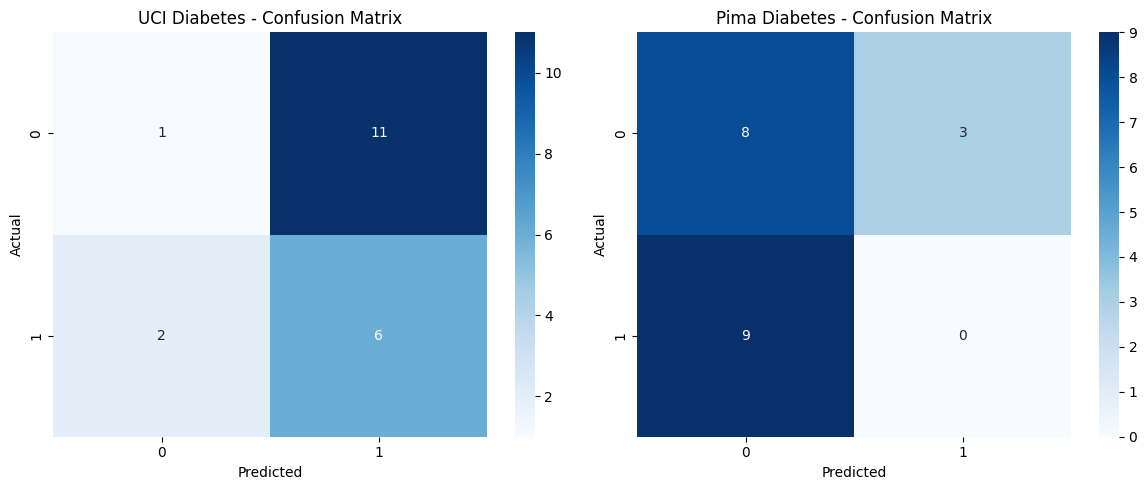

In [9]:
#5B
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create Sample Datasets
np.random.seed(42)

uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100),
    "Outcome": np.random.randint(0, 2, 100)
})

pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 100),
    "BloodPressure": np.random.randint(60, 100, 100),
    "BMI": np.random.uniform(18, 45, 100),
    "Outcome": np.random.randint(0, 2, 100)
})

# Display Sample Data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train the Logistic Regression Models
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate UCI Model
accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci)
recall_uci = recall_score(y_test_uci, y_pred_uci)
f1_uci = f1_score(y_test_uci, y_pred_uci)

# Evaluate Pima Model
accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima)
recall_pima = recall_score(y_test_pima, y_pred_pima)
f1_pima = f1_score(y_test_pima, y_pred_pima)

# Display Results
print("\nUCI Diabetes Dataset - Logistic Regression Results")
print(f"Accuracy : {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall   : {recall_uci:.4f}")
print(f"F1 Score : {f1_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Logistic Regression Results")
print(f"Accuracy : {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall   : {recall_pima:.4f}")
print(f"F1 Score : {f1_pima:.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test_uci, y_pred_uci),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("UCI Diabetes - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test_pima, y_pred_pima),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title("Pima Diabetes - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Sample Dataset:
   Glucose
0      182
1      131
2      172
3       94
4      186


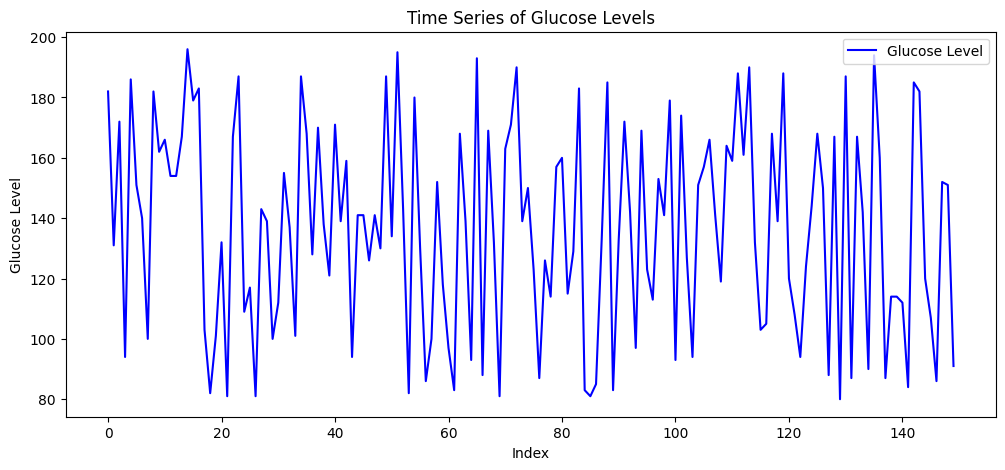

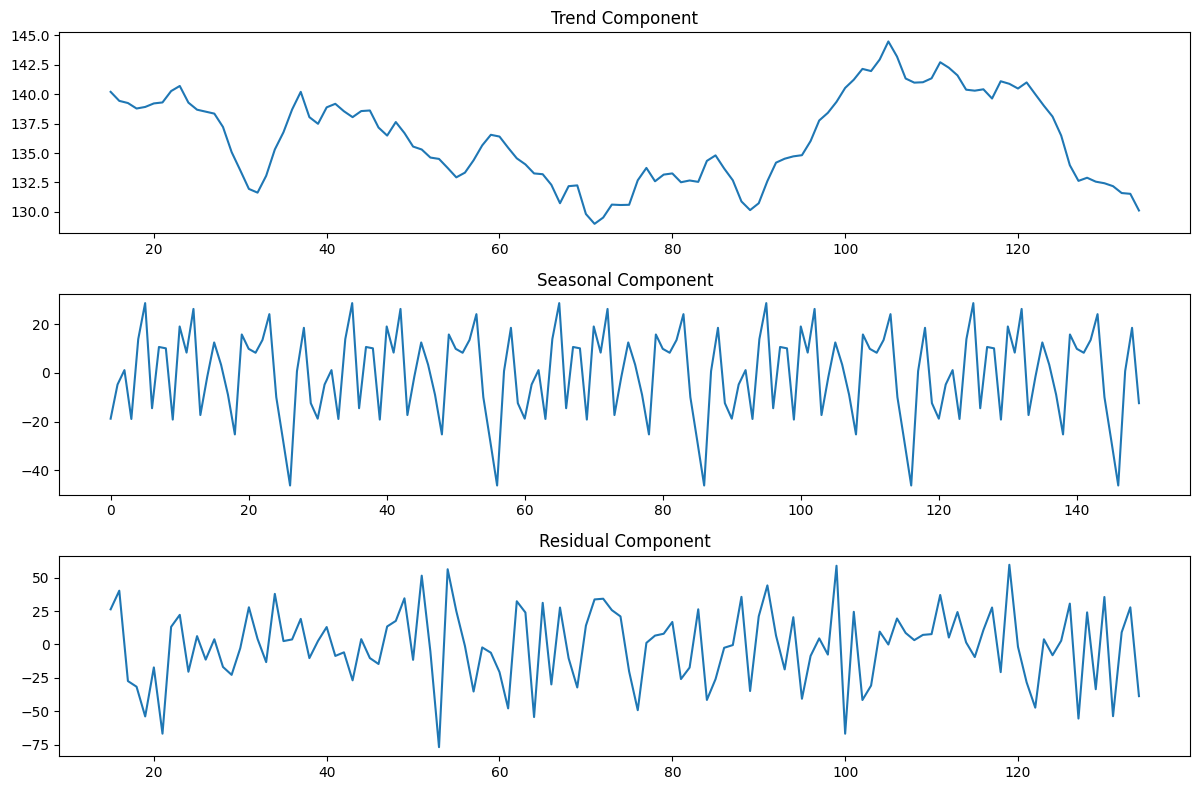

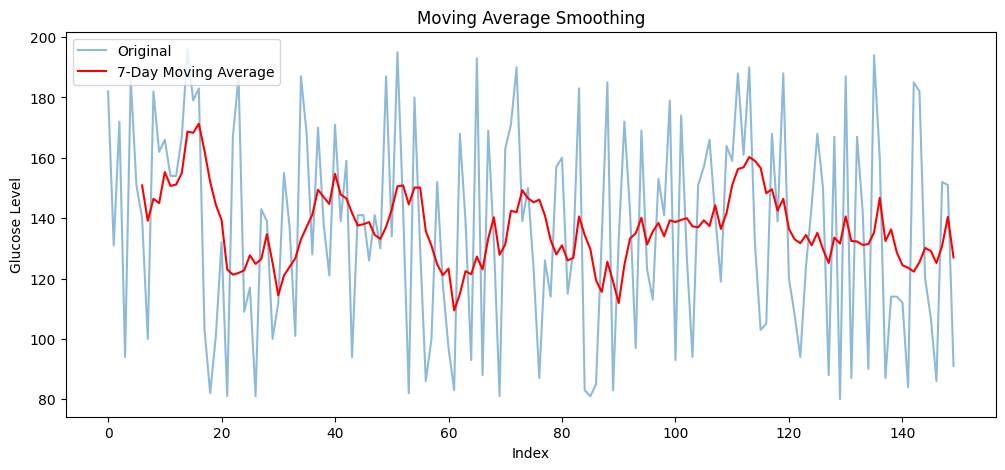

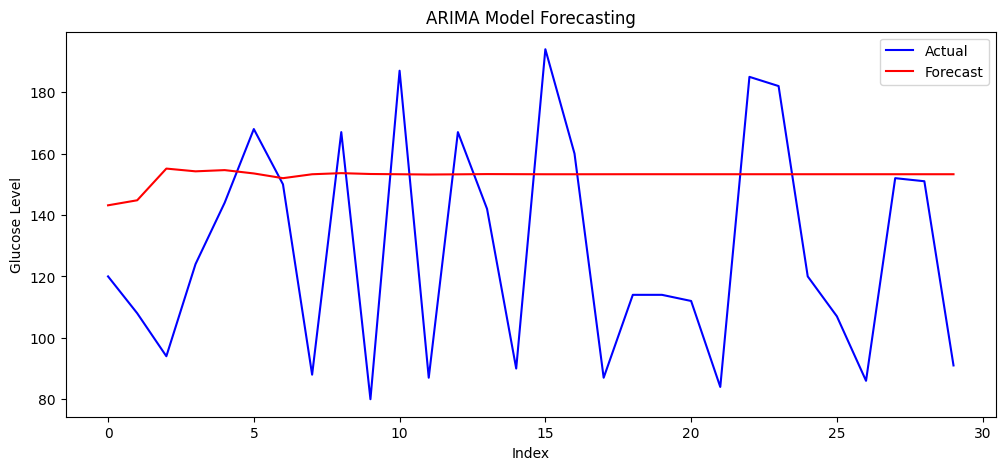

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Create Sample Diabetes Dataset
np.random.seed(42)

diabetes_data = pd.DataFrame({
    "Glucose": np.random.randint(80, 200, 150)
})

# Display first few rows
print("Sample Dataset:")
print(diabetes_data.head())

# Plot Time Series Data
plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], label="Glucose Level", color="blue")
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

# Decompose Time Series into Trend, Seasonality and Residuals
decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

fig, axes = plt.subplots(3, 1, figsize=(12,8))

decomposition.trend.plot(ax=axes[0])
axes[0].set_title("Trend Component")

decomposition.seasonal.plot(ax=axes[1])
axes[1].set_title("Seasonal Component")

decomposition.resid.plot(ax=axes[2])
axes[2].set_title("Residual Component")

plt.tight_layout()
plt.show()

# Apply 7-Day Moving Average
diabetes_data["Glucose_MA"] = diabetes_data["Glucose"].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], label="Original", alpha=0.5)
plt.plot(diabetes_data["Glucose_MA"], label="7-Day Moving Average", color="red")
plt.title("Moving Average Smoothing")
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.legend()
plt.show()

# Split Data into Train and Test
train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

# Build ARIMA Model
model = ARIMA(train, order=(5,1,0))
fitted_model = model.fit()

# Forecast Future Values
forecast = fitted_model.forecast(steps=len(test))

# Plot Forecast vs Actual
plt.figure(figsize=(12,5))
plt.plot(test.values, label="Actual", color="blue")
plt.plot(forecast.values, label="Forecast", color="red")
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("ARIMA Model Forecasting")
plt.legend()
plt.show()